In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

Usando lags porque el modelo v1 es muy malo

In [2]:
df = pd.read_csv("../dataset.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [3]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [4]:
# df = df.loc[(df["fecha"] >= "2024-10-01") & (df["fecha"] <= "2025-06-30")].copy()

# mismo periodo que usamos en text mining

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [5]:
df = df.rename(columns={
    "merval_price_return_ars": "merval",
})

# elimino la otra columna del merval que no vamos a usar
df = df.drop(columns=["merval_total_return_ars"])

In [6]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [7]:
# chequeo de cuantos NAs tenemos en cada columna

pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
merval,0,0.0
embi_spread_arg,2,2.5
embi_spreads_brz,2,2.5
embi_spread_global,2,2.5
emae_original,0,0.0
emae_desestacionalizado,0,0.0
emae_tendencia_ciclo,0,0.0
tc_minorista,0,0.0
tc_mayorista,0,0.0


In [8]:
# Si imputamos deberiamos hacer una extrapolacion lineal entre los 2 valores que rodean al nulo probablemente

In [9]:
# Lags de 1, 2 y 7 días para las variables clave
lags = [1, 2, 5]
cols_to_lag = [
    "merval",
    "embi_spread_arg",
    "embi_spreads_brz",
    "embi_spread_global",
    "emae_original",
    "emae_desestacionalizado",
    "emae_tendencia_ciclo",
    "tc_minorista",
    "tc_mayorista",
    "rrii",
    "tamar",
    "badlar",
    "tm20",
    "tasa_depositos",
    "tasa_prestamos_personales",
    "base_monetaria",
    "circulacion_monetaria",
    "dep_ccorrientes",
    "dep_cahorro",
    "dep_plazo",
    "inflacion_rem",
    "cer",
    "uva",
]

for col in cols_to_lag:
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)

# Eliminar filas con NaN creadas por los lags (las primeras 7)
df = df.dropna().copy()


In [10]:
df = df.dropna().copy()

In [11]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha

In [12]:
X.head(5)

,embi_spread_arg,embi_spreads_brz,embi_spread_global,emae_original,emae_desestacionalizado,emae_tendencia_ciclo,tc_minorista,tc_mayorista,rrii,tamar,...,dep_plazo_lag5,inflacion_rem_lag1,inflacion_rem_lag2,inflacion_rem_lag5,cer_lag1,cer_lag2,cer_lag5,uva_lag1,uva_lag2,uva_lag5
67,558.677,230.085,291.236,146.268674,152.275523,150.730557,1065.68,1037.75,30.904,34.1875,...,49287221.0,21.9,21.9,21.9,5186810.0,5182843.0,5163055.0,1308.84,1307.84,1301.85
68,578.547,228.097,292.350,146.268674,152.275523,150.730557,1066.34,1039.75,31.038,34.1875,...,53699883.0,21.9,21.9,21.9,5190780.0,5186810.0,5167007.0,1309.84,1308.84,1303.84
69,582.954,234.426,296.109,146.268674,152.275523,150.730557,1067.44,1040.25,30.835,34.2500,...,53200265.0,21.9,21.9,21.9,5194752.0,5190780.0,5178880.0,1310.84,1309.84,1304.84
70,579.514,230.315,295.850,146.268674,152.275523,150.730557,1068.04,1041.25,30.704,34.5625,...,53630093.0,21.9,21.9,21.9,5206689.0,5194752.0,5182843.0,1311.85,1310.84,1307.84
71,602.882,228.063,295.790,146.268674,152.275523,150.730557,1068.86,1041.75,30.624,32.8750,...,53610605.0,21.9,21.9,21.9,5210674.0,5206689.0,5186810.0,1314.86,1311.85,1308.84


## Train-Test Split

In [13]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(52, 91)
(14, 91)


## Cross-Validation

In [14]:
# Con 52 días hábiles, conviene usar menos pliegues y bloques de validación más cortos
# - n_splits=3: tres validaciones más estables
# - test_size=10: ~2 semanas hábiles de validación
# - gap=2: separación temporal entre train y test para evitar fuga de informacion

test_size = 10
tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=0)


In [15]:
# rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# param_distributions = {
#     "n_estimators": randint(100, 800),
#     "max_depth": randint(3, 18),
#     "min_samples_split": randint(2, 20),
#     "min_samples_leaf": randint(1, 10),
#     "max_features": ["sqrt", "log2", None],
#     "bootstrap": [True, False],
# }

In [16]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_distributions = {
    "n_estimators": randint(150, 401),
    "max_depth": randint(2, 11),
    "min_samples_split": randint(4, 21),
    "min_samples_leaf": randint(4, 13),
    "max_features": uniform(0.15, 0.35),
    "bootstrap": [True]
}

In [17]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=40,                        # ajustá según tiempo
    scoring="neg_root_mean_squared_error", # multiplica por -1 para mantener la convencion de que mas alto es mejor
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

In [18]:
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=60,
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # útil para auditar overfitting
    error_score=np.nan                       # si algún fold falla, no aborta toda la búsqueda
)

In [19]:
search.fit(X_train, y_train)
best_rf = search.best_estimator_
print("Mejores hiperparámetros:", search.best_params_)
print("CV RMSE promedio:", -search.best_score_)

Fitting 3 folds for each of 60 candidates, totalling 180 fits


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 7, 'max_features': np.float64(0.16156775651519192), 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 296}
CV RMSE promedio: 116682.00222538384


## Test

In [20]:
y_pred = best_rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


Holdout RMSE: 97094.8364
Holdout R²:   -1.0375


In [21]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

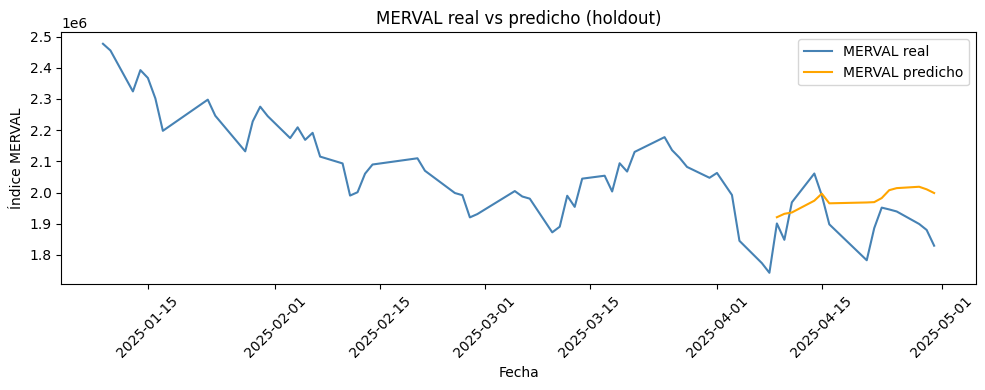

In [22]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


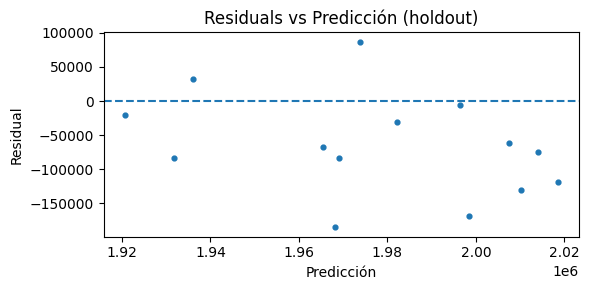

In [23]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


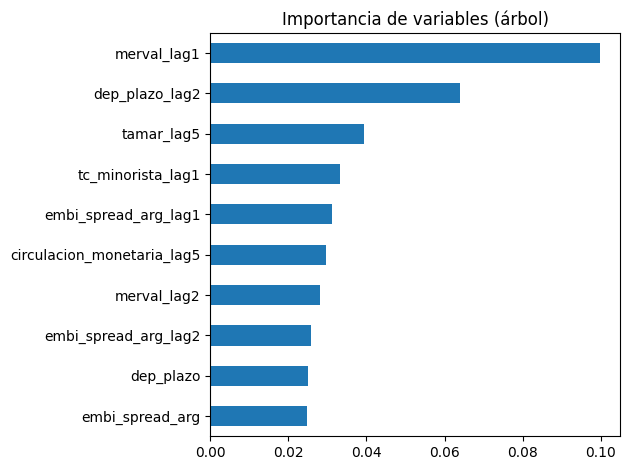

In [24]:
# Importancia de las variables

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(10).plot(kind="barh", title="Importancia de variables (árbol)")
plt.tight_layout(); plt.show()
